Imports

In [32]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

Read dataset

In [23]:
train_path = '/kaggle/input/17flowerclasses/17flowerclasses/train'
test_path = '/kaggle/input/17flowerclasses/17flowerclasses/test'

parameters

In [24]:
batch_size = 32
epochs = 20

Data augmentation

In [25]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, 
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 
)


test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

Generators

In [26]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 952 images belonging to 17 classes.
Found 238 images belonging to 17 classes.
Found 170 images belonging to 17 classes.


Load base model

In [27]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers :
    layer.trainable = False

base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

Custom Layer

In [28]:
model = Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(17, activation='softmax')
])

Train model

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 795ms/step - accuracy: 0.2572 - loss: 2.7278 - val_accuracy: 0.7731 - val_loss: 0.9019
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 534ms/step - accuracy: 0.7435 - loss: 0.8762 - val_accuracy: 0.8319 - val_loss: 0.5732
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 531ms/step - accuracy: 0.8300 - loss: 0.5898 - val_accuracy: 0.8319 - val_loss: 0.5509
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 536ms/step - accuracy: 0.8476 - loss: 0.4640 - val_accuracy: 0.8655 - val_loss: 0.4638
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 530ms/step - accuracy: 0.8795 - loss: 0.3606 - val_accuracy: 0.8697 - val_loss: 0.4654
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 514ms/step - accuracy: 0.9165 - loss: 0.2806 - val_accuracy: 0.8782 - val_loss: 0.3657
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 523ms/step - accuracy: 0.9268 - loss: 0.2539 - val_accuracy: 0.8697 - val_loss: 0.4086
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 535ms/step - accuracy: 0.9271 - loss: 0.2151 - val_accu

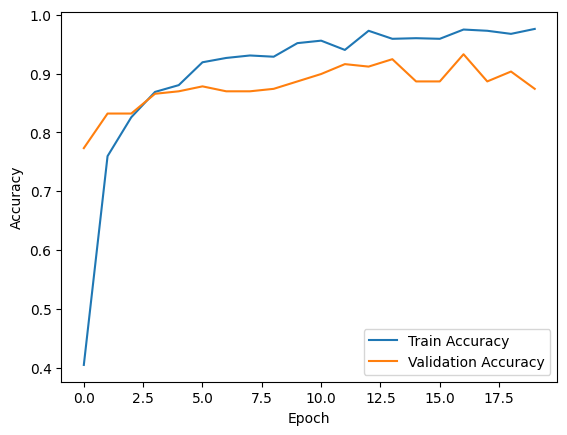

In [29]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Fine tunning 

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 873ms/step - accuracy: 0.9679 - loss: 0.0951 - val_accuracy: 0.8992 - val_loss: 0.2982
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 511ms/step - accuracy: 0.9686 - loss: 0.0739 - val_accuracy: 0.8866 - val_loss: 0.3213
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 513ms/step - accuracy: 0.9850 - loss: 0.0529 - val_accuracy: 0.9034 - val_loss: 0.3468
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 518ms/step - accuracy: 0.9795 - loss: 0.0588 - val_accuracy: 0.8992 - val_loss: 0.2760
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 520ms/step - accuracy: 0.9893 - loss: 0.0514 - val_accuracy: 0.9076 - val_loss: 0.2733


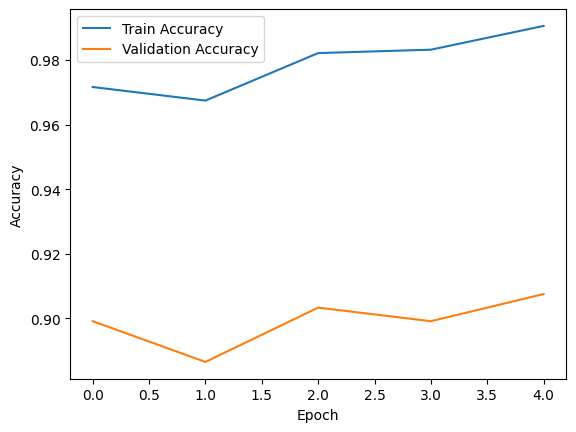

In [30]:
for layer in base_model.layers[-10:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Test

In [34]:


labels = {v: k for k, v in train_generator.class_indices.items()}

def predict_label(model, img_path):
    img = load_img(img_path, target_size=(224, 224))
    
    img_array = img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    pred = model.predict(img_array)

    class_index = np.argmax(pred)

    return labels[class_index]

img_path = "/kaggle/input/flower/6028_SpanishBluebells_CGC8649sq-scaled.jpg"

result = predict_label(model, img_path)

print("Predicted label:", result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted label: Bluebell
